# Preprocesamiento del corpus:
Siguiendo con las conclusiones del notebook anterior, pasamos a realizar el preprocessamiento del corpus para conseguir un corpus limpio y normalizado. Lo primer es traer el csv que creamos con las tan solo 5000 muestras balanceadas en dos clases:sentimiento positivo y negativo.

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd

! cd /content/drive/MyDrive/practica_NPL

path = "/content/drive/MyDrive/practica_NPL"

data_books_balanceado = pd.read_csv(f'{path}/corpus_final.csv')
data_books_balanceado = data_books_balanceado.dropna(subset=['text', 'sentiment'])

print(data_books_balanceado.head())
data_books_balanceado["sentiment"].value_counts()

   rating                                               text  sentiment
0     2.0  The main character, Diane, was hard to identif...          0
1     2.0  Several pages had pictures cut out by scissors...          0
2     5.0  I spent $40 on the audio book which makes it t...          1
3     5.0  Wow! This is one of the very best books I have...          1
4     2.0  I have to say when I first bought this book I ...          0


,count
sentiment,
0,2500
1,2500


Como se ha comentado en el anterior notebook, y como hemos ido viendo en clase, los pasos habituales seguidos en el preprocesamiento son los siguientes:
- Tokenizar
- Pasar a minusculas
- Quitar etiquetas de html
- Quitar espacios si necesario y puntos u otros signos de puntuación
- Pasar todo a letras (transformar numéros a letras, eliminar símbolos extraños, quitar acentos)
- filtrar por STOPWORDS (que debe ser actualizado)
- lemmatización

Todo ello no se hace necesariamente en el orden expuesto, pero si que es cierto que se suele hacer una funcion PIPELINE que englobe todo esto (y así se pide en el enunciado). Asimismo existen dos grandes librerias que se han estudiado en el módulo para el preprocesamiento: Spacy y NLTK. Aunque se podrían utilizar solo una de ellas, se va a hacer un popurri de estas junto a otras.

Empezamos por lo más claro en este corpus:

## Eliminación etiquetas HTML:

In [78]:
#COMO VISTO EN CLASE:
from bs4 import BeautifulSoup

def eliminar_html(texto):
    return BeautifulSoup(texto, "html.parser").get_text(" ")

## Filtros sobre el caracteres (normalización del texto -> minusculas, tokenizar, eliminar simbolos,signos de putuación y espacios, trasnformar numeros en palabras)


In [17]:
!pip install num2words

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 5.4 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=1ff883106428a04f2989753bfbe50204ba71a976d51f76f8f5e47aad1f24affc
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


In [95]:
#SE UTILIZAN LAS DISTINTAS LIBRERIAS VISTAS EN CLASE
import numpy as np
import unicodedata
import re
from num2words import num2words
def normalizacion_texto(text):
    text = text.lower() #pasar a minusculas
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore") #quita acentos
    text = re.sub(r"[$€£]\s*(\d+(?:\.\d+)?)", r"\1", text) #se ha visto en ejemplos que hay precios
    palabras = text.split()
    palabras_normalizadas = []
    for word in palabras:
        if word.isdigit():
            word = num2words(int(word), lang='en', ordinal=False) #convierte numeros en palabras
        palabras_normalizadas.append(word)
    text = " ".join(palabras_normalizadas)
    text = re.sub(r"[^a-z'\s]", " ", text) #quita cualquier simbolo/signo que no sea letra
    text = re.sub(r"\s+", " ", text).strip() #quita espacios que haya demás
    palabras = text.split() #tokeniza
    return palabras

In [96]:
normalizacion_texto("hola me llamo $40 JDUDÚsiíca jejej 50         años ten don't go que! bien!!1^][]")

['hola',
 'me',
 'llamo',
 'forty',
 'jdudusiica',
 'jejej',
 'fifty',
 'anos',
 'ten',
 "don't",
 'go',
 'que',
 'bien']

## Filtrar stopwords

En este caso, como ya se comento en el anterior book, va s er interesante modificar la lista de STOPWORDS predefinida por la libreria nltk. Por ejemplo, palabras como "never" o "no"de negación puede llegar a ser relevantes a la hora de comprender el sentimiento negativo.
Del mismo modo, se podria pensar sobre libro pues es el tema a tratar, pero hay que  pensar que al poder captar la dependencia de palabras, no podemos eliminar libro  de frases como "good book".

In [97]:
#COMO EN CLASE: secogen las stopwords e ingles porque así están escritas las reviews

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

STOPWORDS_EN = set(stopwords.words("english"))

NEGATIONS = {"no", "not", "nor", "never", "n't"}
STOPWORDS_EN_CUSTOM = STOPWORDS_EN - NEGATIONS
def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS_EN_CUSTOM]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Lemmatización

In [53]:
!pip -q install spacy
!python -m spacy download en_core_web_sm -q

In [98]:
#COMO VISTO EN CLASE:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
def lematizacion(tokens):
    doc = nlp(" ".join(tokens))
    tokens_limpios = [token.lemma_ for token in doc]
    return tokens_limpios

## Pipeline - Función principal

uniendo todas las funciones presentadas anteriormente:

In [99]:
def preprocess_corpus(texto):
    if not isinstance(texto, str):
        return "Hay un error, no se ha introducido un string"
    # ELIMINAR HTML
    texto = eliminar_html(texto)

    # NORMALIZACION + TOKENIZACION
    tokens = normalizacion_texto(texto)

    # FILTRO STOPWORDS
    tokens = remove_stopwords(tokens)

    # LEMATIZACION
    tokens = lematizacion(tokens)

    return " ".join(tokens)

## Aplicación preproesamiento:

Una vez hayamos definido la función general de preprocesameinto, se lo aplicamos al corpus, creando una nueva columna. De esta manera se podrá hacer una pequeña prueba final para verificar que funciona correctamente.

In [100]:
data_books_balanceado["text_preprocessed"] = data_books_balanceado["text"].apply(preprocess_corpus)

data_books_balanceado["text_preprocessed"] = data_books_balanceado["text_preprocessed"].replace("", np.nan)
data_books_balanceado = data_books_balanceado.dropna(subset=["text_preprocessed"]).reset_index(drop=True)

data_books_balanceado[["text", "text_preprocessed"]].head()

,text,text_preprocessed
0,"The main character, Diane, was hard to identif...",main character diane hard identify entire stor...
1,Several pages had pictures cut out by scissors...,several page picture cut scissor also underlin...
2,I spent $40 on the audio book which makes it t...,spend forty audio book make expensive shell no...
3,Wow! This is one of the very best books I have...,wow one good book read quite base actual event...
4,I have to say when I first bought this book I ...,say first buy book think worth not worth not k...


In [101]:
for i in range(5):
    print("---- RAW ----")
    print(data_books_balanceado.loc[i, "text"][:250])
    print("---- CLEAN ----")
    print(data_books_balanceado.loc[i, "text_preprocessed"][:250])

---- RAW ----
The main character, Diane, was hard to identify with.  The entire story was about anorexia and cutting.  It was so very overdone.<br /><br />The ending was quite disappointing and hard to digest.  Not Ms. Clark's best.
---- CLEAN ----
main character diane hard identify entire story anorexia cut overdone end quite disappointing hard digest not ms clark 's good
---- RAW ----
Several pages had pictures cut out by scissors.  Also underlining with red pen throughout book.
---- CLEAN ----
several page picture cut scissor also underline red pen throughout book
---- RAW ----
I spent $40 on the audio book which makes it the most expensive I've shelled out for. I was not disappointed (although did curse Johnny Depp for changing voices then found they had two readers who sounded completely different and ultimately Richards 
---- CLEAN ----
spend forty audio book make expensive shell not disappoint although curse johnny depp change voice find two reader sound completely different ult

In [102]:
from collections import Counter

vocab_raw = set(" ".join(data_books_balanceado["text"].str.lower()).split())
vocab_clean = set(" ".join(data_books_balanceado["text_preprocessed"].str.lower()).split())

print("Vocab raw:", len(vocab_raw))
print("Vocab clean:", len(vocab_clean))

Vocab raw: 58519
Vocab clean: 21679


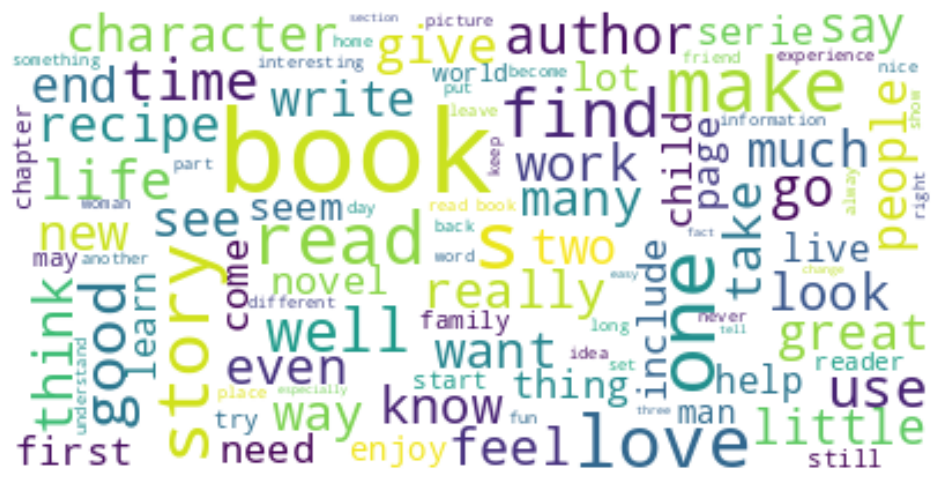

[('book', 4689), ('not', 2057), ('read', 1730), ("'s", 1710), ('one', 1652), ('like', 1264), ('love', 1216), ('make', 1205), ('story', 1135), ('good', 1066), ('well', 959), ('find', 928), ('get', 862), ('time', 806), ('life', 746), ('also', 739), ('great', 712), ('would', 695), ('author', 691), ('go', 647)]


In [109]:
#SEGUN EL ANTERIOR NOTEBOOK PARA VERIFICAR EL AVANCE
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

textos_positivos = data_books_balanceado[data_books_balanceado["sentiment"] == 1]["text_preprocessed"].astype(str).str.lower()
palabras_total_pos = []

for review in textos_positivos:
    frases_review = review.split(".")
    for frase in frases_review:
        palabras_frase = frase.split()
        palabras_total_pos.extend(palabras_frase)

def plot_word_cloud(text):
    wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(' '.join(text))
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()
plot_word_cloud(palabras_total_pos)


print(Counter(palabras_total_pos).most_common(20))

Observando los distintos ejemplos para verificar que el texto haya sido limpiado y normalizado correctamente, podemos concluir que se  ha conseguido. En comparacion, con lo que veiamos en el notebook anterior,donde teniamos etiquetas de html, y muchisimas palabras repetidas sobre determinantes que ahora no aparecen.
Se puede ver que se ha hecho una limpieza exhastiva de los tokens, reduciendo a más de la mitad estos. Por tanto, se guarda esto en un csv que se utilizará en el siguiente notebook.

In [110]:
data_books_balanceado.to_csv(f"{path}/corpus_final_limpio.csv", index=False)

Se ha decidido de nuevo posponer la creación y visualización del word embedding al siguiente notebook. En este se hará la  división del datset en train y test, y no se producirá ningún data leakage a la hora de extraer las caracteristicas, transformando las palabras en vectores.